# Neural Network Exercises
For these exercises we'll perform a binary classification on the Census Income dataset available from the <a href = 'http://archive.ics.uci.edu/ml/datasets/Adult'>UC Irvine Machine Learning Repository</a><br>
The goal is to determine if an individual earns more than $50K based on a set of continuous and categorical variables.

## Census Income Dataset
For this exercises we're using the Census Income dataset available from the <a href='http://archive.ics.uci.edu/ml/datasets/Adult'>UC Irvine Machine Learning Repository</a>.

The full dataset has 48,842 entries. For this exercise we have reduced the number of records, fields and field entries, and have removed entries with null values. The file <strong>income.csv</strong> has	30,000 entries

Each entry contains the following information about an individual:
* <strong>age</strong>: the age of an individual as an integer from 18 to 90 (continuous)
* <strong>sex</strong>: Male or Female (categorical)
* <strong>education</strong>: represents the highest level of education achieved by an individual (categorical)
* <strong>education_num</strong>: represents education as an integer from 3 to 16 (categorical)
<div><table style="display: inline-block">
<tr><td>3</td><td>5th-6th</td><td>8</td><td>12th</td><td>13</td><td>Bachelors</td></tr>
<tr><td>4</td><td>7th-8th</td><td>9</td><td>HS-grad</td><td>14</td><td>Masters</td></tr>
<tr><td>5</td><td>9th</td><td>10</td><td>Some-college</td><td>15</td><td>Prof-school</td></tr>
<tr><td>6</td><td>10th</td><td>11</td><td>Assoc-voc</td><td>16</td><td>Doctorate</td></tr>
<tr><td>7</td><td>11th</td><td>12</td><td>Assoc-acdm</td></tr>
</table></div>
* <strong>marital-status</strong>: marital status of an individual (categorical)
<div><table style="display: inline-block">
<tr><td>Married</td><td>Divorced</td><td>Married-spouse-absent</td></tr>
<tr><td>Separated</td><td>Widowed</td><td>Never-married</td></tr>
</table></div>
* <strong>workclass</strong>: a general term to represent the employment status of an individual (categorical)
<div><table style="display: inline-block">
<tr><td>Local-gov</td><td>Private</td></tr>
<tr><td>State-gov</td><td>Self-emp</td></tr>
<tr><td>Federal-gov</td></tr>
</table></div>
* <strong>occupation</strong>: the general type of occupation of an individual (categorical)
<div><table style="display: inline-block">
<tr><td>Adm-clerical</td><td>Handlers-cleaners</td><td>Protective-serv</td></tr>
<tr><td>Craft-repair</td><td>Machine-op-inspct</td><td>Sales</td></tr>
<tr><td>Exec-managerial</td><td>Other-service</td><td>Tech-support</td></tr>
<tr><td>Farming-fishing</td><td>Prof-specialty</td><td>Transport-moving</td></tr>
</table></div>
* <strong>hours-per-week</strong>: the hours an individual has reported to work per week as an integer from 20 to 90 (continuous)
* <strong>income</strong>: whether or not an individual makes more than \\$50,000 annually (label)
* <strong>label</strong>: income represented as an integer (0: <=\\$50K, 1: >\\$50K) (optional label)

## Perform standard imports
Run the cell below to load the libraries needed for this exercise and the Census Income dataset.

In [3]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
%matplotlib inline

df = pd.read_csv('./DATA/income.csv')

In [4]:
print(len(df))
df.head()

30000


,age,sex,education,education-num,marital-status,workclass,occupation,hours-per-week,income,label
0,27,Male,HS-grad,9,Never-married,Private,Craft-repair,40,<=50K,0
1,47,Male,Masters,14,Married,Local-gov,Exec-managerial,50,>50K,1
2,59,Male,HS-grad,9,Divorced,Self-emp,Prof-specialty,20,<=50K,0
3,38,Female,Prof-school,15,Never-married,Federal-gov,Prof-specialty,57,>50K,1
4,64,Female,11th,7,Widowed,Private,Farming-fishing,40,<=50K,0


In [5]:
df['label'].value_counts()

label
0    21700
1     8300
Name: count, dtype: int64

### 1. Separate continuous, categorical and label column names
You should find that there are 5 categorical columns, 2 continuous columns and 1 label.<br>
In the case of <em>education</em> and <em>education-num</em> it doesn't matter which column you use. For the label column, be sure to use <em>label</em> and not <em>income</em>.<br>
Assign the variable names "cat_cols", "cont_cols" and "y_col" to the lists of names.

In [6]:
df.columns

Index(['age', 'sex', 'education', 'education-num', 'marital-status',
       'workclass', 'occupation', 'hours-per-week', 'income', 'label'],
      dtype='object')

In [7]:
cat_cols = ['sex', 'education', 'marital-status', 'workclass', 'occupation']
cont_cols = ['age', 'hours-per-week']
y_col = ['label']

print(f'cat_cols  has {len(cat_cols)} columns')
print(f'cont_cols has {len(cont_cols)} columns')
print(f'y_col     has {len(y_col)} column')

cat_cols  has 5 columns
cont_cols has 2 columns
y_col     has 1 column


### 2. Convert categorical columns to category dtypes

In [11]:
for col in cat_cols:
    df[col] = df[col].astype('category')
    
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             30000 non-null  int64   
 1   sex             30000 non-null  category
 2   education       30000 non-null  category
 3   education-num   30000 non-null  int64   
 4   marital-status  30000 non-null  category
 5   workclass       30000 non-null  category
 6   occupation      30000 non-null  category
 7   hours-per-week  30000 non-null  int64   
 8   income          30000 non-null  object  
 9   label           30000 non-null  int64   
dtypes: category(5), int64(4), object(1)
memory usage: 1.3+ MB


### 3. Set the embedding sizes
Create a variable "cat_szs" to hold the number of categories in each variable.<br>
Then create a variable "emb_szs" to hold the list of (category size, embedding size) tuples.

In [20]:
cat_szs = [len(df[col].cat.categories) for col in cat_cols]
emb_szs = [(size, min(50, (size+1)//2)) for size in cat_szs]
emb_szs

[(2, 1), (14, 7), (6, 3), (5, 3), (12, 6)]

### 4. Create an array of categorical values
Create a NumPy array called "cats" that contains a stack of each categorical column <tt>.cat.codes.values</tt><br>
Note: your output may contain different values. Ours came after performing the shuffle step shown above.

In [25]:
cats = [df[col].cat.codes.values for col in cat_cols]
cats = np.stack(cats, 1)

# RUN THIS CODE TO COMPARE RESULTS
cats[:5]

array([[ 1, 10,  3,  2,  1],
       [ 1, 11,  1,  1,  2],
       [ 1, 10,  0,  3,  7],
       [ 0, 12,  3,  0,  7],
       [ 0,  1,  5,  2,  3]], dtype=int8)

### 5. Convert "cats" to a tensor
Convert the "cats" NumPy array to a tensor of dtype <tt>int64</tt>

In [26]:
# CODE HERE
cats = torch.tensor(cats, dtype=torch.int64)
cats, cats.dtype

(tensor([[ 1, 10,  3,  2,  1],
         [ 1, 11,  1,  1,  2],
         [ 1, 10,  0,  3,  7],
         ...,
         [ 1, 12,  1,  2,  7],
         [ 0, 13,  3,  2,  0],
         [ 1,  6,  1,  3,  2]]),
 torch.int64)

### 6. Create an array of continuous values
Create a NumPy array called "conts" that contains a stack of each continuous column.<br>
Note: your output may contain different values. Ours came after performing the shuffle step shown above.

In [27]:
# CODE HERE
conts = [df[col].values for col in cont_cols]
conts = np.stack(conts, 1)

# RUN THIS CODE TO COMPARE RESULTS
conts[:5]

array([[27, 40],
       [47, 50],
       [59, 20],
       [38, 57],
       [64, 40]])

### 7. Convert "conts" to a tensor
Convert the "conts" NumPy array to a tensor of dtype <tt>float32</tt>

In [28]:
conts = torch.tensor(conts, dtype=torch.float32)

conts.dtype

torch.float32

### 8. Create a label tensor
Create a tensor called "y" from the values in the label column. Be sure to flatten the tensor so that it can be passed into the CE Loss function.

In [29]:
# CODE HERE
y = torch.tensor(df['label'].values)

### 9. Create train and test sets from <tt>cats</tt>, <tt>conts</tt>, and <tt>y</tt>
We use the entire batch of 30,000 records, but a smaller batch size will save time during training.<br>
We used a test size of 5,000 records, but you can choose another fixed value or a percentage of the batch size.<br>
Make sure that your test records remain separate from your training records, without overlap.<br>
To make coding slices easier, we recommend assigning batch and test sizes to simple variables like "b" and "t".

In [37]:
batch_size = 30000
test_size = 5000

cat_train = cats[:batch_size-test_size]
cat_test = cats[batch_size-test_size:batch_size]
conts_train = conts[:batch_size-test_size]
conts_test = conts[batch_size-test_size:batch_size]
y_train = y[:batch_size-test_size]
y_test = y[batch_size-test_size:batch_size]

### Define the TabularModel class

In [56]:
class TablularModel(nn.Module):
    
    def __init__(self, emb_szs, n_cont, out_sz, layers, p=0.5):
        super().__init__()
        self.emb_drop = nn.Dropout(p)
        self.batch_norm = nn.BatchNorm1d(n_cont)
        self.embeds = nn.ModuleList([
            nn.Embedding(unique_category_size, emb_dim) for (unique_category_size, emb_dim) in emb_szs
        ])
        
        input_size = n_cont + sum((emb_dim for unique_category_size, emb_dim in emb_szs))
        
        layerlist = []
        for i in layers:
            layerlist.append(nn.Linear(input_size, i))
            layerlist.append(nn.ReLU(inplace=True))
            layerlist.append(nn.BatchNorm1d(i))
            layerlist.append(nn.Dropout(p))
            input_size = i
            
        layerlist.append(nn.Linear(layers[-1], out_sz))
        
        self.nn_layers = nn.Sequential(*layerlist)
        
    def forward(self, x_cat, x_conts):
        
        x_conts = self.batch_norm(x_conts)
        
        embeddings = []
        for i, e in enumerate(self.embeds):
            embeddings.append(e(x_cat[:,i]))
        x = torch.cat(embeddings, 1)
        x = self.emb_drop(x)
        
        x = torch.cat([x, x_conts], 1)
        
        return self.nn_layers(x)

### 10. Set the random seed
To obtain results that can be recreated, set a torch manual_seed (we used 33).

In [57]:
# CODE HERE
torch.manual_seed(33)

### 11. Create a TabularModel instance
Create an instance called "model" with one hidden layer containing 50 neurons and a dropout layer p-value of 0.4

In [75]:
tabluar_model = TablularModel(emb_szs, len(cont_cols), 2, [50])

tabluar_model

TablularModel(
  (emb_drop): Dropout(p=0.5, inplace=False)
  (batch_norm): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (embeds): ModuleList(
    (0): Embedding(2, 1)
    (1): Embedding(14, 7)
    (2): Embedding(6, 3)
    (3): Embedding(5, 3)
    (4): Embedding(12, 6)
  )
  (nn_layers): Sequential(
    (0): Linear(in_features=22, out_features=50, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=50, out_features=2, bias=True)
  )
)

### 12. Define the loss and optimization functions
Create a loss function called "criterion" using CrossEntropyLoss<br>
Create an optimization function called "optimizer" using Adam, with a learning rate of 0.001

In [76]:
# CODE HERE
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tabluar_model.parameters(), lr=0.001)

### Train the model

In [77]:
import time
start_time = time.time()

epochs = 300
losses = []

for i in range(epochs):
    
    tabluar_model.train()
    
    i+=1
    y_pred = tabluar_model(cat_train, conts_train)
    loss = criterion(y_pred, y_train)
    losses.append(loss.detach().numpy())
    
    # a neat trick to save screen space:
    if i%25 == 1:
        print(f'epoch: {i:3}  loss: {loss.item():10.8f}')

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f'epoch: {i:3}  loss: {loss.item():10.8f}')
print(f'\nDuration: {time.time() - start_time:.0f} seconds')

epoch:   1  loss: 0.81049299
epoch:  26  loss: 0.56695729
epoch:  51  loss: 0.49025011
epoch:  76  loss: 0.44740739
epoch: 101  loss: 0.42573094
epoch: 126  loss: 0.40752825
epoch: 151  loss: 0.39148152
epoch: 176  loss: 0.38062042
epoch: 201  loss: 0.36777192
epoch: 226  loss: 0.36050504
epoch: 251  loss: 0.35342360
epoch: 276  loss: 0.34878278
epoch: 300  loss: 0.34213278

Duration: 48 seconds


### 13. Plot the Cross Entropy Loss against epochs

Text(0.5, 0, 'epoch')

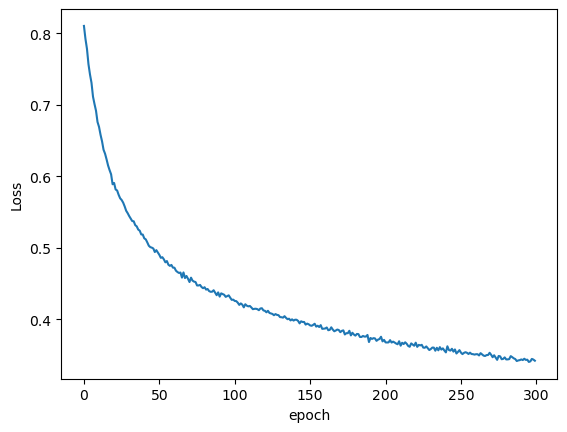

In [78]:
plt.plot(range(epochs), losses)
plt.ylabel('Loss')
plt.xlabel('epoch')

### 14. Evaluate the test set

In [79]:
with torch.inference_mode():
    tabluar_model.eval()
    y_val = tabluar_model(cat_test, conts_test)
    loss = criterion(y_val, y_test)
    
print(f'CE Loss: {loss:.8f}')

CE Loss: 0.29887792


### 15. Calculate the overall percent accuracy

In [84]:
correct = 0
for i in range(len(y_val)):
    if y_val[i].argmax().item() == y_test[i]:
        correct += 1
print(f'{correct} out of {len(y_val)}')

4355 out of 5000
